# XGBoost: predictive performance

Predict two-year recidivism (`Two_yr_Recidivism`) on the COMPAS cohort with XGBoost. Training lives in `xgb_model.py` (run it once to save the model to `models/`); the metrics live in `performance.py`. This notebook loads the saved model and shows the results.

- Shared stratified 70/30 train/test split (`compas_scoring.data.train_test`), so results are comparable with the other models.
- Hyperparameters picked by a randomized search with 5-fold CV on the **training set only**.
- The test set is used once, to report performance next to the incumbent COMPAS score.

In [1]:
%load_ext autoreload
%autoreload 2

In [10]:
import sys

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt

from performance import confusion, performance_table, roc_data, scores, load_xper
from xgb_model import load_data, load_metadata, load_model

## 1. Data

Feature set FS1 (`race_aware`): all 10 predictors. Change `FEATURE_SET` to `"selected"` (FS2) or `"race_blind"` (FS3) to rerun on the other sets.

In [4]:
FEATURE_SET = "race_aware"

train, test = load_data(FEATURE_SET)
print(f"{len(train)} train rows, {len(test)} test rows")
print(f"Recidivism rate - train: {train.base_rate:.3f}, test: {test.base_rate:.3f}")
train.X.head()

4320 train rows, 1852 test rows
Recidivism rate - train: 0.455, test: 0.455


,Number_of_Priors,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 2. Saved model

Trained and tuned by `python xgboost/xgb_model.py`.

In [5]:
model = load_model(FEATURE_SET)
meta = load_metadata(FEATURE_SET)

print(f"Best CV AUC: {meta['cv_auc']:.4f}")
meta["best_params"]

Best CV AUC: 0.7245


{'subsample': 0.9,
 'reg_lambda': 1.0,
 'n_estimators': 100,
 'min_child_weight': 10,
 'max_depth': 4,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 1.0}

## 3. Predictive performance

Threshold 0.5. COMPAS is only available as a high/low label (`score_factor`), so its AUC and Brier score are those of a single cut-off.

In [6]:
performance_table(model, test)

,auc,accuracy,precision,recall,f1,brier
XGBoost,0.7329,0.6830,0.6834,0.5658,0.6191,0.2140
COMPAS (incumbent),0.6575,0.6614,0.6320,0.6133,0.6225,0.3386


In [7]:
confusion(model, test)

,predicted: no,predicted: yes
actual: no reoffence,788,221
actual: reoffence,366,477


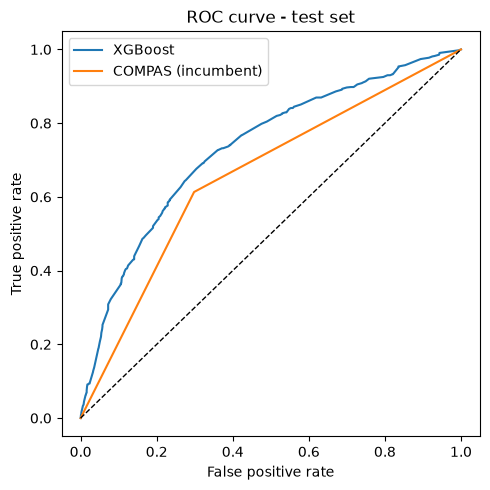

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, y_score in [("XGBoost", scores(model, test)), ("COMPAS (incumbent)", test.incumbent)]:
    roc = roc_data(test.y, y_score)
    ax.plot(roc.fpr, roc.tpr, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set(xlabel="False positive rate", ylabel="True positive rate", title="ROC curve - test set")
ax.legend()
plt.show()

In [ ]:
from XPER.viz.Visualisation import visualizationClass as viz

In [ ]:

phi, phi_i = load_xper(FEATURE_SET)
xper_test = test.subset(phi_i.index)  # the rows XPER was computed on

viz.bar_plot(
    XPER_values=(phi.to_numpy(), phi_i.to_numpy()),
    X_test=xper_test.X,
    labels=list(xper_test.X.columns),
    p=len(xper_test.X.columns),  
    percentage=True,
)

/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/python3.13/site-packages/XPER/viz/Visualisation.py:264: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  benchmark_ind_i = benchmark_v_ind.iloc[ind_i][0]
/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/python3.13/site-packages/XPER/viz/Visualisation.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X=X[XPER > 0][index_sort_pos],
/home/hitaishi/Documents/HEC/02_Interpretability_stability_algorithmic fairness/project/ThinkCarefully/.venv/lib/p

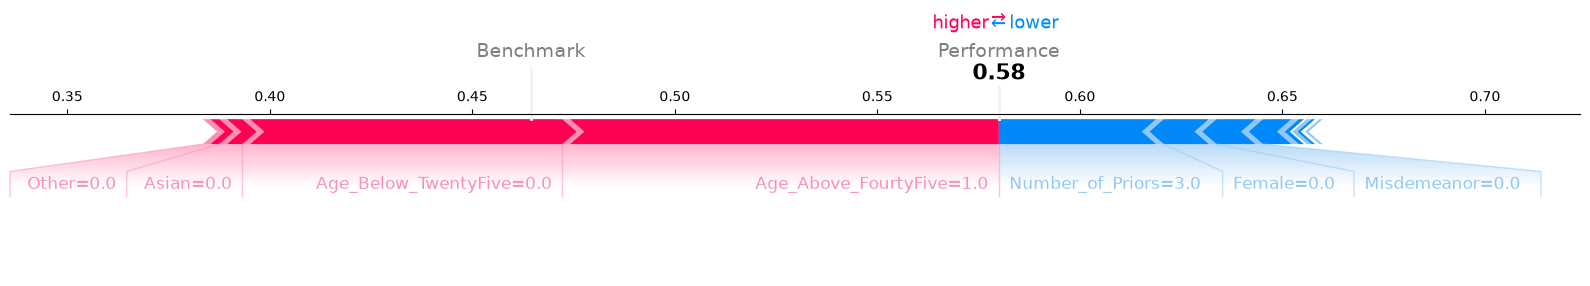

In [16]:
viz.force_plot(XPER_values=(phi.to_numpy(), phi_i.to_numpy()), 
               instance=5, 
               X_test=xper_test.X,
               variable_name=list(xper_test.X.columns), 
               figsize=(16,4))